In [1]:
import sys
sys.path.append('../')
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from itertools import combinations

In [2]:
def plot_separate_pairwise_histograms(
    pickle_file_path_without_disentanglement, 
    pickle_file_path_with_disentanglement,
    save_dir, 
    N_value,
    y_max=None
):
    """
    Load user representations from two pickle files (with and without disentanglement),
    compute pairwise cosine similarities, and plot separate histograms side by side for comparison.

    Args:
        pickle_file_path_without_disentanglement (str): Path to the pickle file without disentanglement.
        pickle_file_path_with_disentanglement (str): Path to the pickle file with disentanglement.
        save_dir (str): Directory to save the histograms.
        N_value (int): The value of N (e.g., 5, 10, 25, 50).
        y_max (float, optional): Maximum limit for the y-axis. Default is None.

    Returns:
        str: Path to the saved combined histogram.
    """
    os.makedirs(save_dir, exist_ok=True)

    fig, axs = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

    for ax, pickle_file_path, label, color in zip(
        axs,
        [pickle_file_path_without_disentanglement, pickle_file_path_with_disentanglement],
        [f'N={N_value} (Without Disentanglement)', f'N={N_value} (With Disentanglement)'],
        ['blue', 'orange']
    ):
        # Load user representations
        with open(pickle_file_path, 'rb') as f:
            user_representations = pickle.load(f)
        if not isinstance(user_representations, np.ndarray):
            user_representations = np.array(user_representations)

        # Compute pairwise cosine similarities for individual users
        avg_pairwise_similarities = []
        for user_rep in user_representations:
            pairwise_similarities = []
            for pair in combinations(user_rep, 2):
                cos_sim = np.dot(pair[0], pair[1]) / (np.linalg.norm(pair[0]) * np.linalg.norm(pair[1]))
                pairwise_similarities.append(cos_sim)
            avg_pairwise_similarity = np.mean(pairwise_similarities)
            avg_pairwise_similarities.append(avg_pairwise_similarity)

        # Plot histogram of average pairwise cosine similarities
        ax.hist(avg_pairwise_similarities, bins=50, alpha=0.5, color=color, histtype='stepfilled', rwidth=0.9)
        ax.set_title(label)
        ax.set_xlabel('Cosine Similarity')
        if y_max is not None:
            ax.set_ylim(0, y_max)
    
    axs[0].set_ylabel('Frequency')
    plt.suptitle(f'Comparison of Average Pairwise Cosine Similarities for N={N_value}')
    combined_histogram_path = os.path.join(save_dir, f'separate_pairwise_cosine_similarities_N{N_value}.png')
    plt.savefig(combined_histogram_path)
    plt.show()
    plt.close()
    print(f'Saved separate histograms for N={N_value} at {combined_histogram_path}')

    return combined_histogram_path

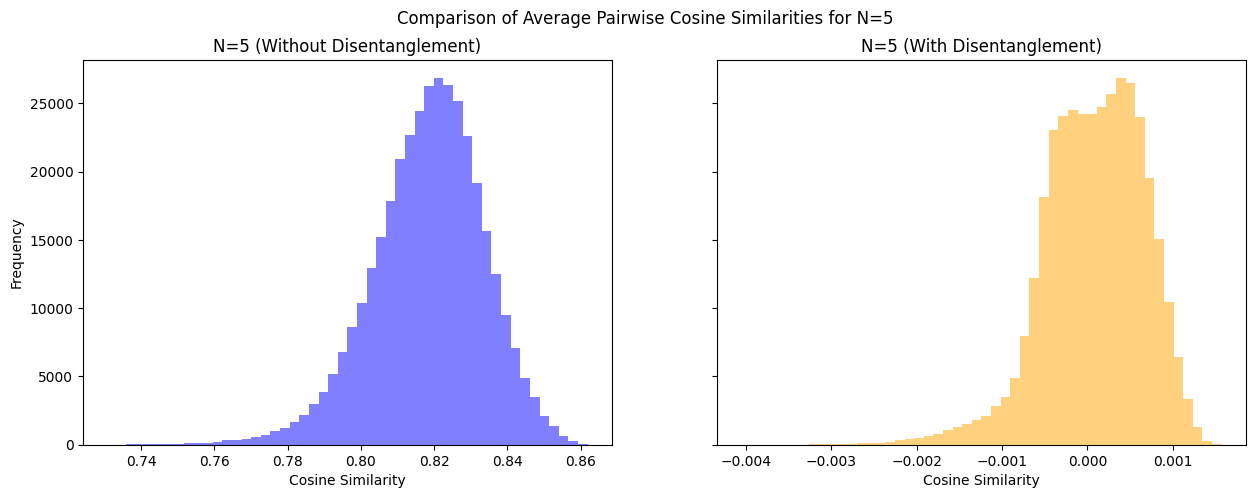

Saved separate histograms for N=5 at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/candidate_rep/separate_pairwise_cosine_similarities_N5.png


'/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/candidate_rep/separate_pairwise_cosine_similarities_N5.png'

In [3]:
# Paths for N=5
plot_separate_pairwise_histograms(
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N5_user_representations/user_representations.pkl',
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N5_dis_cos_bce_lamda_s_0.9/user_representations.pkl',
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/candidate_rep',
    5
)

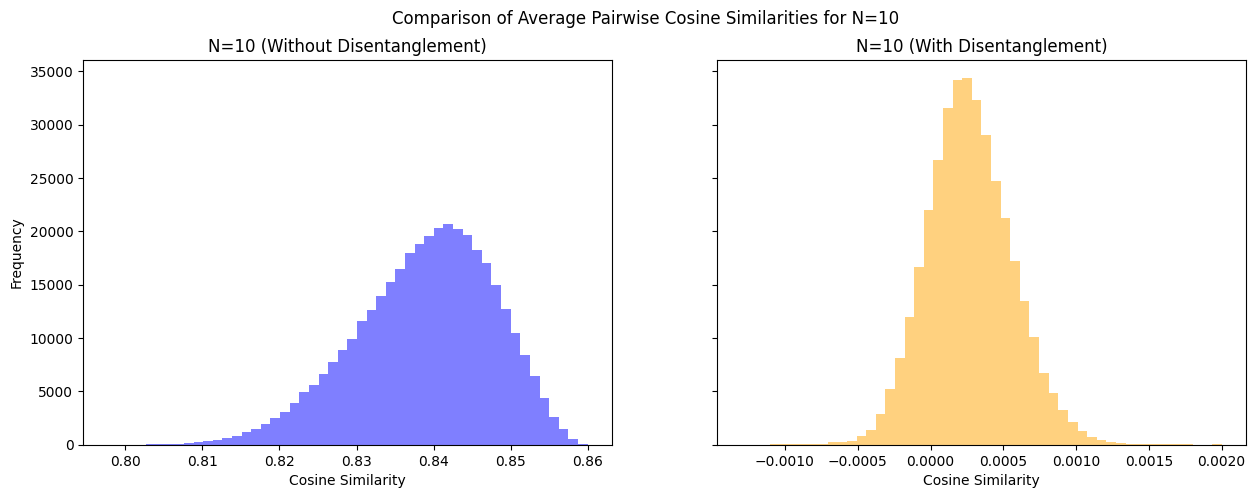

Saved separate histograms for N=10 at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/candidate_rep/separate_pairwise_cosine_similarities_N10.png


'/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/candidate_rep/separate_pairwise_cosine_similarities_N10.png'

In [4]:
# Paths for N=10
plot_separate_pairwise_histograms(
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N10_user_representations/user_representations.pkl',
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N10_dis_cos_bce_lamda_s_0.9_user_representations/user_representations.pkl',
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/candidate_rep',
    10
)

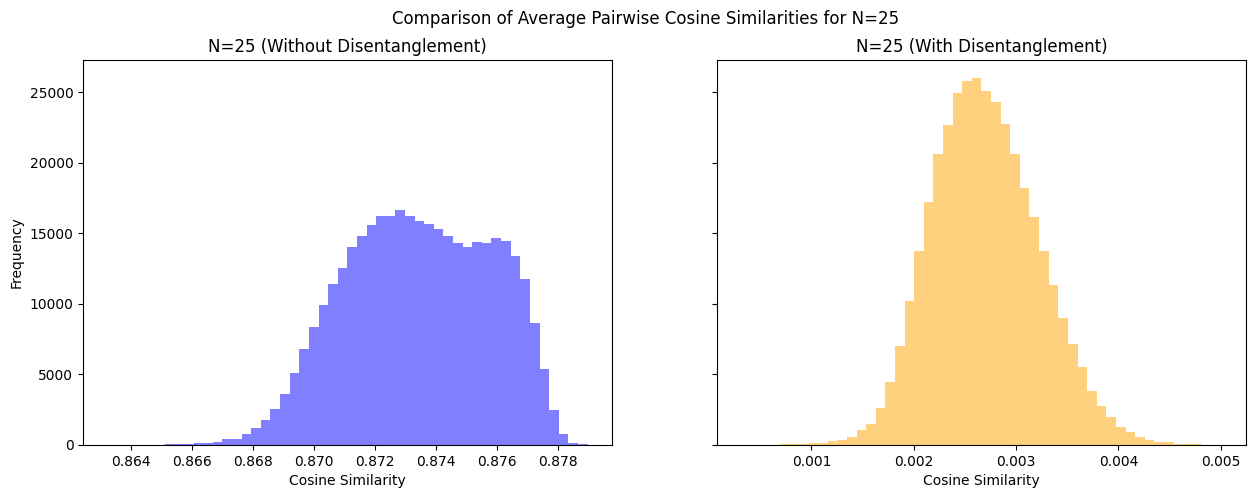

Saved separate histograms for N=25 at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/candidate_rep/separate_pairwise_cosine_similarities_N25.png


'/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/candidate_rep/separate_pairwise_cosine_similarities_N25.png'

In [5]:
# Paths for N=25
plot_separate_pairwise_histograms(
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N25_user_representations/user_representations.pkl',
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N25_dis_cos_bce_lamda_s_0.9/user_representations.pkl',
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/candidate_rep',
    25
)

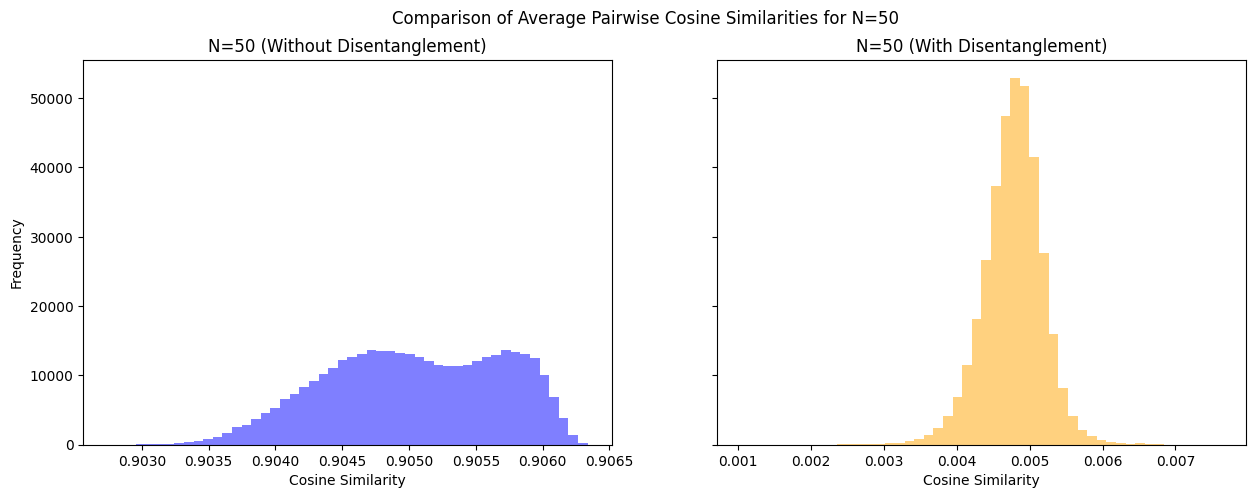

Saved separate histograms for N=50 at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/candidate_rep/separate_pairwise_cosine_similarities_N50.png


'/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/candidate_rep/separate_pairwise_cosine_similarities_N50.png'

In [6]:
# Paths for N=50
plot_separate_pairwise_histograms(
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N50_user_representations/user_representations.pkl',
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N50_dis_cos_bce_lamda_s_0.90/user_representations.pkl',
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/candidate_rep',
    50
)

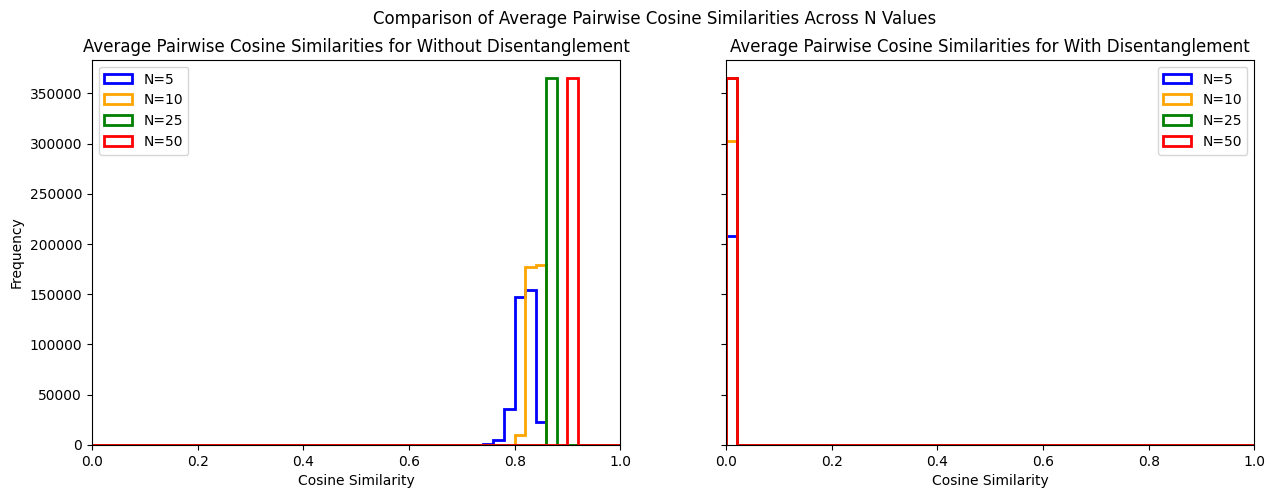

Saved combined histogram at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/cosine_similarities_merged_plots/combined_pairwise_cosine_similarities.png


In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

def plot_pairwise_cosine_histogram(ax, avg_pairwise_similarities, label, color):
    """
    Plot a histogram of average pairwise cosine similarities on the provided axis using 'step' histtype for more detailed visualization.

    Args:
        ax (matplotlib.axes.Axes): The axis on which to plot the histogram.
        avg_pairwise_similarities (list): List of average pairwise cosine similarities to plot.
        label (str): Label for the histogram (used in the legend).
        color (str): Color of the histogram outline.
    """
    ax.hist(avg_pairwise_similarities, bins=50, histtype='step', linewidth=2, color=color, label=label, range=(0.0, 1.0))
    ax.set_xlim(0.0, 1.0)  # Ensure the x-axis goes from 0 to 1.0

def compute_pairwise_cosine_similarities(user_representations):
    """
    Compute average pairwise cosine similarities for individual users.

    Args:
        user_representations (np.ndarray): Array of user representations.

    Returns:
        list: Average pairwise cosine similarities for each user.
    """
    avg_pairwise_similarities = []
    for user_rep in user_representations:
        pairwise_similarities = []
        for pair in combinations(user_rep, 2):
            cos_sim = np.dot(pair[0], pair[1]) / (np.linalg.norm(pair[0]) * np.linalg.norm(pair[1]))
            pairwise_similarities.append(cos_sim)
        avg_pairwise_similarity = np.mean(pairwise_similarities)
        avg_pairwise_similarities.append(avg_pairwise_similarity)
    return avg_pairwise_similarities

def plot_combined_pairwise_histograms(pickle_files, labels, save_dir):
    """
    Plot combined histograms of average pairwise cosine similarities for all N values.

    Args:
        pickle_files (dict): A dictionary with keys "Without Disentanglement" and "With Disentanglement",
                             each containing a list of paths to pickle files for different N values.
        labels (list): A list of labels corresponding to each N value.
        save_dir (str): Directory to save the plots.

    Returns:
        str: Path to the saved combined histogram.
    """
    os.makedirs(save_dir, exist_ok=True)

    colors = ['blue', 'orange', 'green', 'red']  # Colors for each N value

    fig, axs = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

    for ax, key, title in zip(
        axs,
        ["Without Disentanglement", "With Disentanglement"],
        ["Without Disentanglement", "With Disentanglement"]
    ):
        for i, (pickle_file, label) in enumerate(zip(pickle_files[key], labels)):
            # Load user representations
            with open(pickle_file, 'rb') as f:
                user_representations = pickle.load(f)
            if not isinstance(user_representations, np.ndarray):
                user_representations = np.array(user_representations)

            # Compute average pairwise cosine similarities for individual users
            avg_pairwise_similarities = compute_pairwise_cosine_similarities(user_representations)

            # Plot histogram of average pairwise cosine similarities
            plot_pairwise_cosine_histogram(ax, avg_pairwise_similarities, label=label, color=colors[i])

        ax.set_title(f'Average Pairwise Cosine Similarities for {title}')
        ax.set_xlabel('Cosine Similarity')
        ax.legend()

    axs[0].set_ylabel('Frequency')

    plt.suptitle(f'Comparison of Average Pairwise Cosine Similarities Across N Values')
    combined_histogram_path = os.path.join(save_dir, 'combined_pairwise_cosine_similarities.png')
    plt.savefig(combined_histogram_path)
    plt.show()
    plt.close()
    print(f'Saved combined histogram at {combined_histogram_path}')

    return combined_histogram_path

# Example Usage

pickle_files = {
    "Without Disentanglement": [
        '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N5_user_representations/user_representations.pkl',
        '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N10_user_representations/user_representations.pkl',
        '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N25_user_representations/user_representations.pkl',
        '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N50_user_representations/user_representations.pkl'
    ],
    "With Disentanglement": [
        '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N5_dis_cos_bce_lamda_s_0.9/user_representations.pkl',
        '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N10_dis_cos_bce_lamda_s_0.9_user_representations/user_representations.pkl',
        '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N25_dis_cos_bce_lamda_s_0.9/user_representations.pkl',
        '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N50_dis_cos_bce_lamda_s_0.90/user_representations.pkl'
    ]
}

labels = ['N=5', 'N=10', 'N=25', 'N=50']

# Plot combined histograms
combined_histogram_path = plot_combined_pairwise_histograms(
    pickle_files,
    labels,
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/cosine_similarities_merged_plots'
)


In [2]:
def plot_combined_pairwise_histograms(
    pickle_file_path_without_disentanglement, 
    pickle_file_path_with_disentanglement,
    save_dir, 
    N_value,
    y_max=None
):
    """
    Load user representations from two pickle files (with and without disentanglement),
    compute pairwise cosine similarities, and plot combined histograms for comparison.

    Args:
        pickle_file_path_without_disentanglement (str): Path to the pickle file without disentanglement.
        pickle_file_path_with_disentanglement (str): Path to the pickle file with disentanglement.
        save_dir (str): Directory to save the histograms.
        N_value (int): The value of N (e.g., 5, 10, 25, 50).
        y_max (float, optional): Maximum limit for the y-axis. Default is None.

    Returns:
        tuple: Paths to the saved combined histograms (linear and log scale).
    """
    os.makedirs(save_dir, exist_ok=True)

    for scale in ['linear', 'log']:
        plt.figure(figsize=(10, 5))

        for pickle_file_path, label, color in zip(
            [pickle_file_path_without_disentanglement, pickle_file_path_with_disentanglement],
            [f'N={N_value} (Without Disentanglement)', f'N={N_value} (With Disentanglement)'],
            ['blue', 'orange']
        ):
            # Load user representations
            with open(pickle_file_path, 'rb') as f:
                user_representations = pickle.load(f)
            if not isinstance(user_representations, np.ndarray):
                user_representations = np.array(user_representations)

            # Compute pairwise cosine similarities for individual users
            avg_pairwise_similarities = []
            for user_rep in user_representations:
                pairwise_similarities = []
                for pair in combinations(user_rep, 2):
                    cos_sim = np.dot(pair[0], pair[1]) / (np.linalg.norm(pair[0]) * np.linalg.norm(pair[1]))
                    pairwise_similarities.append(cos_sim)
                avg_pairwise_similarity = np.mean(pairwise_similarities)
                avg_pairwise_similarities.append(avg_pairwise_similarity)

            # Plot histogram of average pairwise cosine similarities
            plt.hist(avg_pairwise_similarities, bins=50, alpha=0.5, label=label, color=color, histtype='stepfilled', rwidth=0.9, log=(scale=='log'))

        plt.title(f'Comparison of Average Pairwise Cosine Similarities for N={N_value} ({scale.capitalize()} Scale)')
        plt.xlabel('Cosine Similarity')
        plt.ylabel(f'Frequency ({scale.capitalize()} Scale)')
        plt.legend(loc='upper right')
        if y_max is not None:
            plt.ylim(0, y_max if scale == 'linear' else 1)
        combined_histogram_path = os.path.join(save_dir, f'combined_pairwise_cosine_similarities_N{N_value}_{scale}.png')
        plt.savefig(combined_histogram_path)
        plt.show()
        plt.close()
        print(f'Saved combined histogram for N={N_value} ({scale.capitalize()} Scale) at {combined_histogram_path}')

    return combined_histogram_path

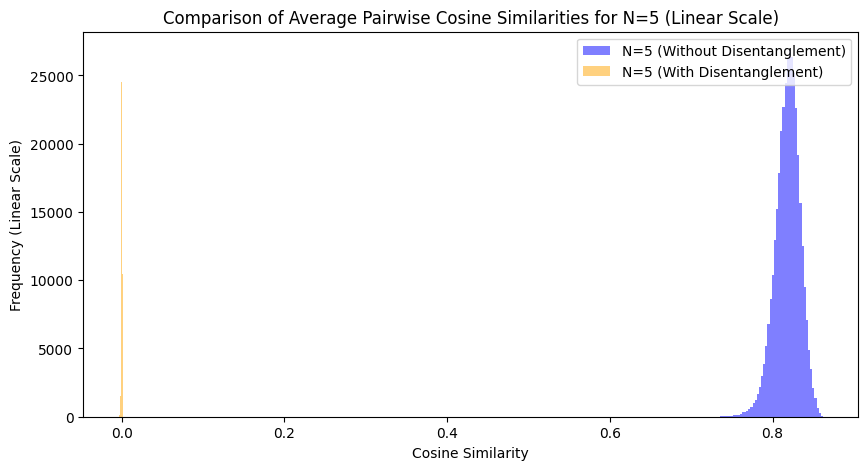

Saved combined histogram for N=5 (Linear Scale) at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/candidate_rep/combined_pairwise_cosine_similarities_N5_linear.png


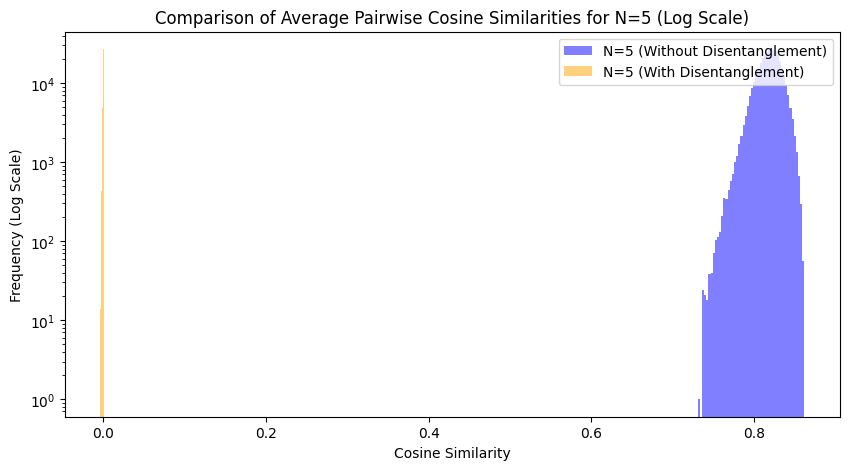

Saved combined histogram for N=5 (Log Scale) at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/candidate_rep/combined_pairwise_cosine_similarities_N5_log.png


'/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/candidate_rep/combined_pairwise_cosine_similarities_N5_log.png'

In [8]:
# Paths for N=5
plot_combined_pairwise_histograms(
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N5_user_representations/user_representations.pkl',
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N5_dis_cos_bce_lamda_s_0.9/user_representations.pkl',
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/candidate_rep',
    5
)

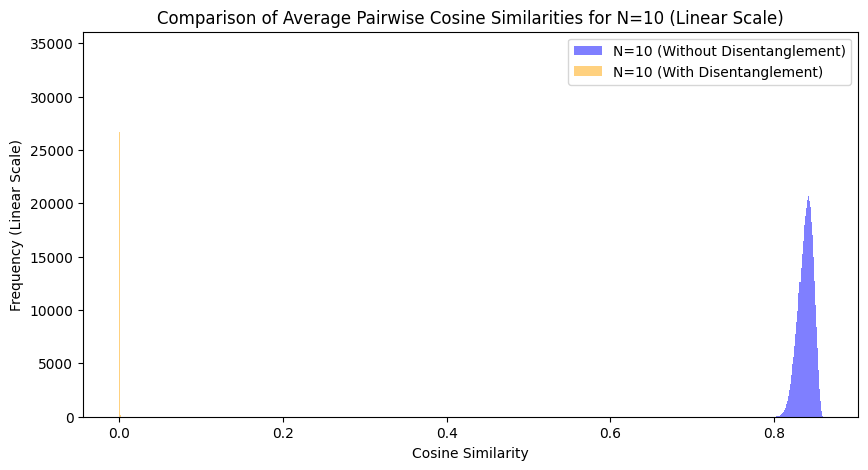

Saved combined histogram for N=10 (Linear Scale) at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/candidate_rep/combined_pairwise_cosine_similarities_N10_linear.png


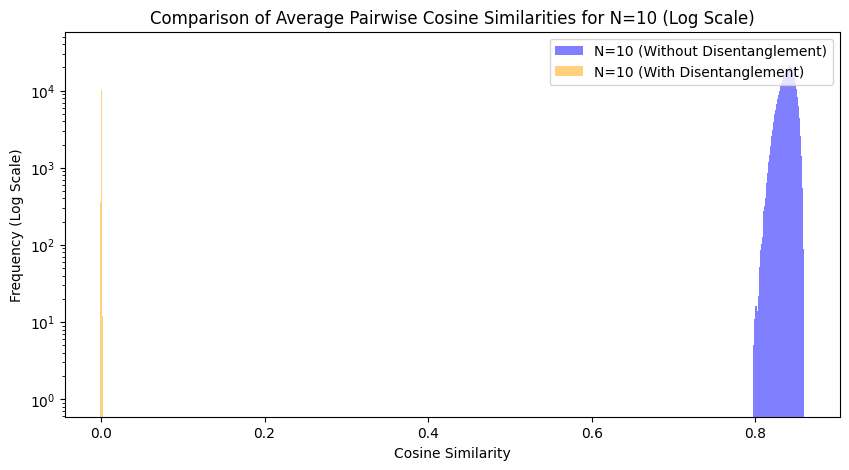

Saved combined histogram for N=10 (Log Scale) at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/candidate_rep/combined_pairwise_cosine_similarities_N10_log.png


'/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/candidate_rep/combined_pairwise_cosine_similarities_N10_log.png'

In [9]:
# Paths for N=10
plot_combined_pairwise_histograms(
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N10_user_representations/user_representations.pkl',
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N10_dis_cos_bce_lamda_s_0.9_user_representations/user_representations.pkl',
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/candidate_rep',
    10
)

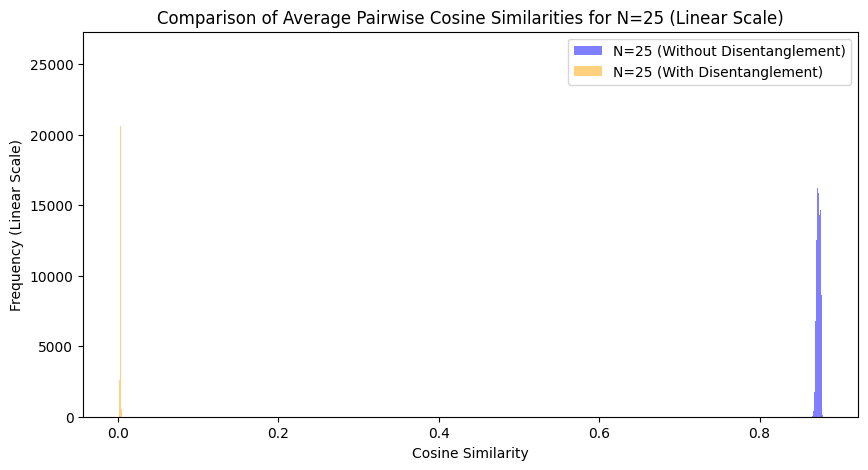

Saved combined histogram for N=25 (Linear Scale) at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/candidate_rep/combined_pairwise_cosine_similarities_N25_linear.png


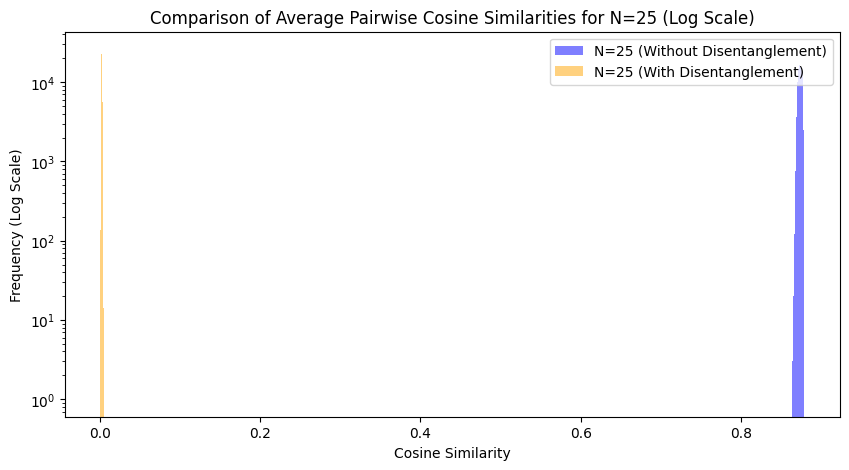

Saved combined histogram for N=25 (Log Scale) at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/candidate_rep/combined_pairwise_cosine_similarities_N25_log.png


'/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/candidate_rep/combined_pairwise_cosine_similarities_N25_log.png'

In [10]:
# Paths for N=25
plot_combined_pairwise_histograms(
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N25_user_representations/user_representations.pkl',
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N25_dis_cos_bce_lamda_s_0.9/user_representations.pkl',
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/candidate_rep',
    25
)

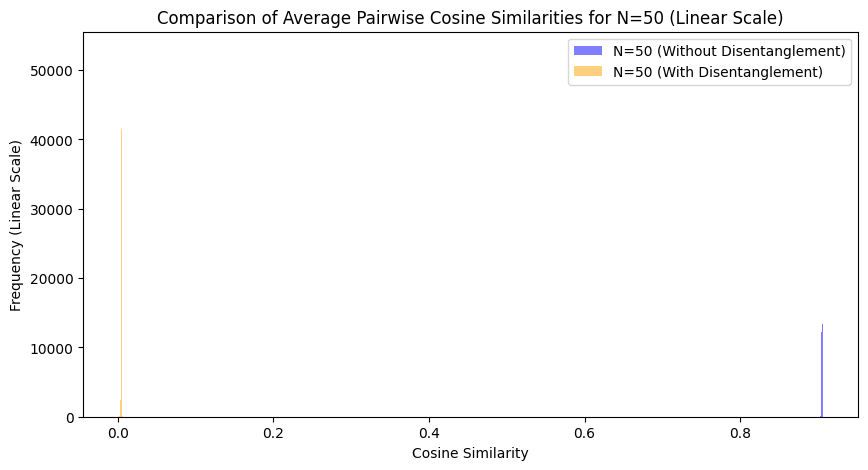

Saved combined histogram for N=50 (Linear Scale) at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/candidate_rep/combined_pairwise_cosine_similarities_N50_linear.png


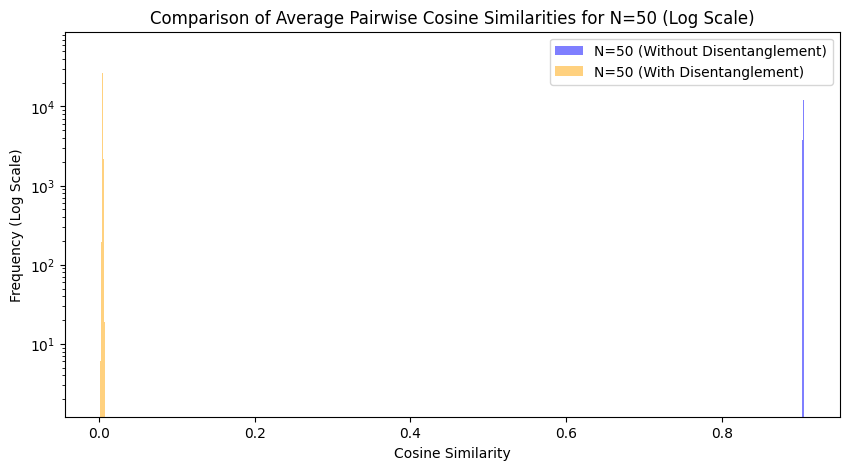

Saved combined histogram for N=50 (Log Scale) at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/candidate_rep/combined_pairwise_cosine_similarities_N50_log.png


'/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/candidate_rep/combined_pairwise_cosine_similarities_N50_log.png'

In [3]:
# Paths for N=50
plot_combined_pairwise_histograms(
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N50_user_representations/user_representations.pkl',
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N50_dis_cos_bce_lamda_s_0.90/user_representations.pkl',
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/candidate_rep',
    50
)